# Clustering Analysis – East-West Airlines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")

file_path = r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 15\EastWestAirlines.xlsx"
try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    df = pd.read_excel("/mnt/data/EastWestAirlines.xlsx")

print("Shape:", df.shape)
display(df.head())

Shape: (3999, 12)


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


## 1. Preprocessing & EDA

In [2]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Count"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe().T)

Missing values:


,Missing Count
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
ID#,3999.0,2014.819455,1160.764358,1.0,1010.5,2016.0,3020.5,4021.0
Balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,1.0,3.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,1.0,1.0,5.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
Bonus_trans,3999.0,11.601900,9.603810,0.0,3.0,12.0,17.0,86.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
Flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,0.0,1.0,53.0


In [4]:
# ID is only an identifier and is excluded from clustering.
# Convert all remaining columns to numeric where possible.
features = [c for c in df.columns if c != "ID#"]
X_raw = df[features].apply(pd.to_numeric, errors="coerce")

# Median imputation
X_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_raw),
    columns=features
)

# Simple outlier treatment: winsorize at 1st/99th percentile.
# This limits extreme values without deleting customers.
X_clean = X_imp.copy()
for col in X_clean.columns:
    lo, hi = X_clean[col].quantile([0.01, 0.99])
    X_clean[col] = X_clean[col].clip(lo, hi)

# Standardize because clustering is distance-based.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print("Prepared feature matrix:", X_scaled.shape)

Prepared feature matrix: (3999, 11)


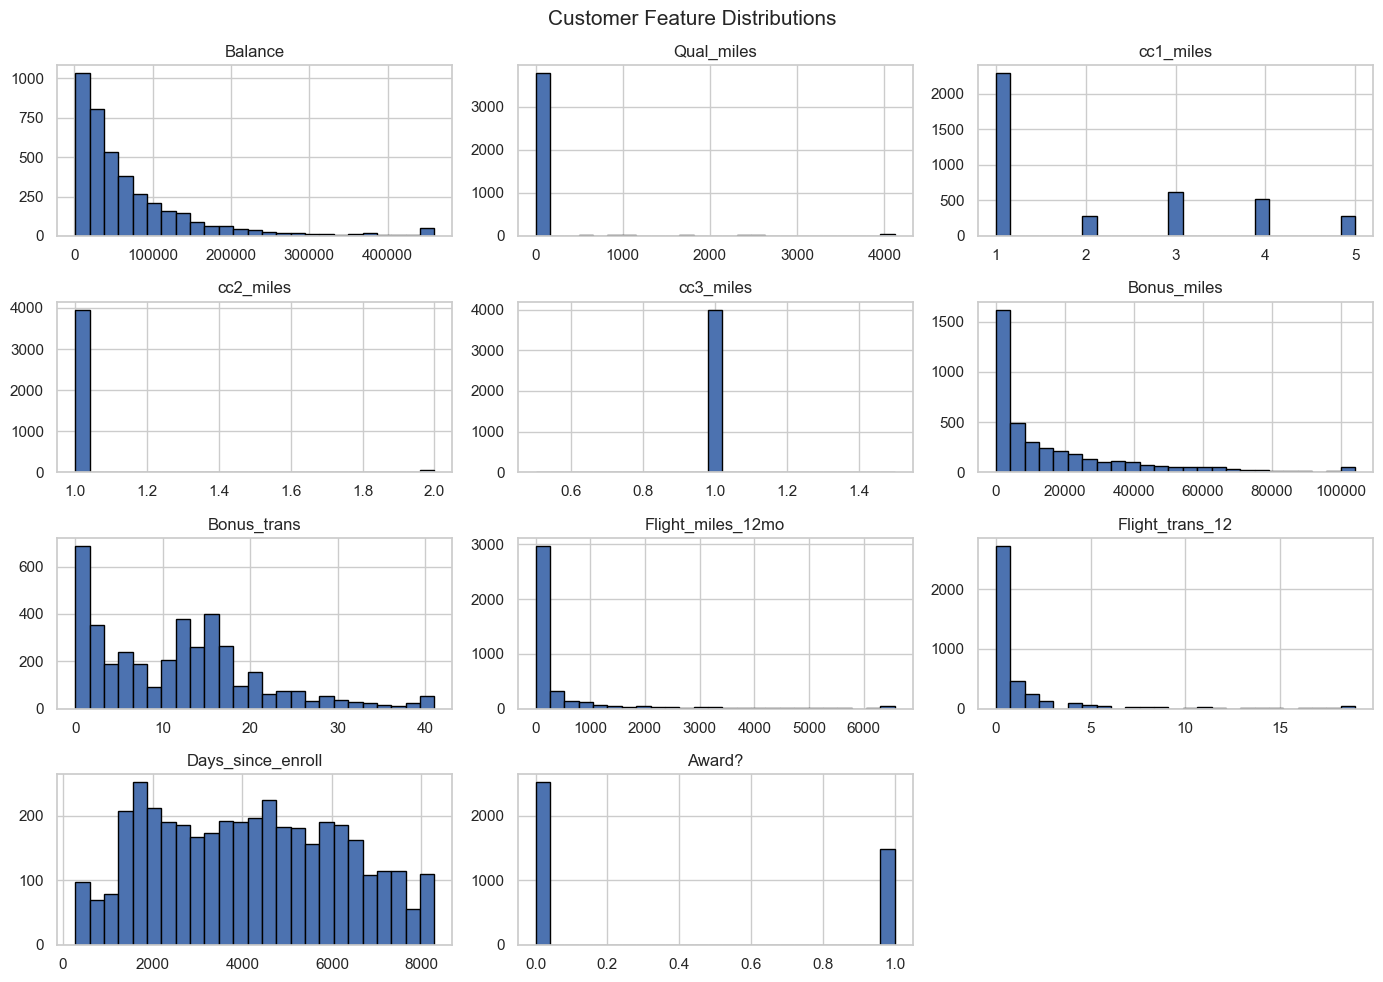

In [5]:
# Distributions
X_clean.hist(figsize=(14, 10), bins=25, edgecolor="black")
plt.suptitle("Customer Feature Distributions", fontsize=15)
plt.tight_layout()
plt.show()

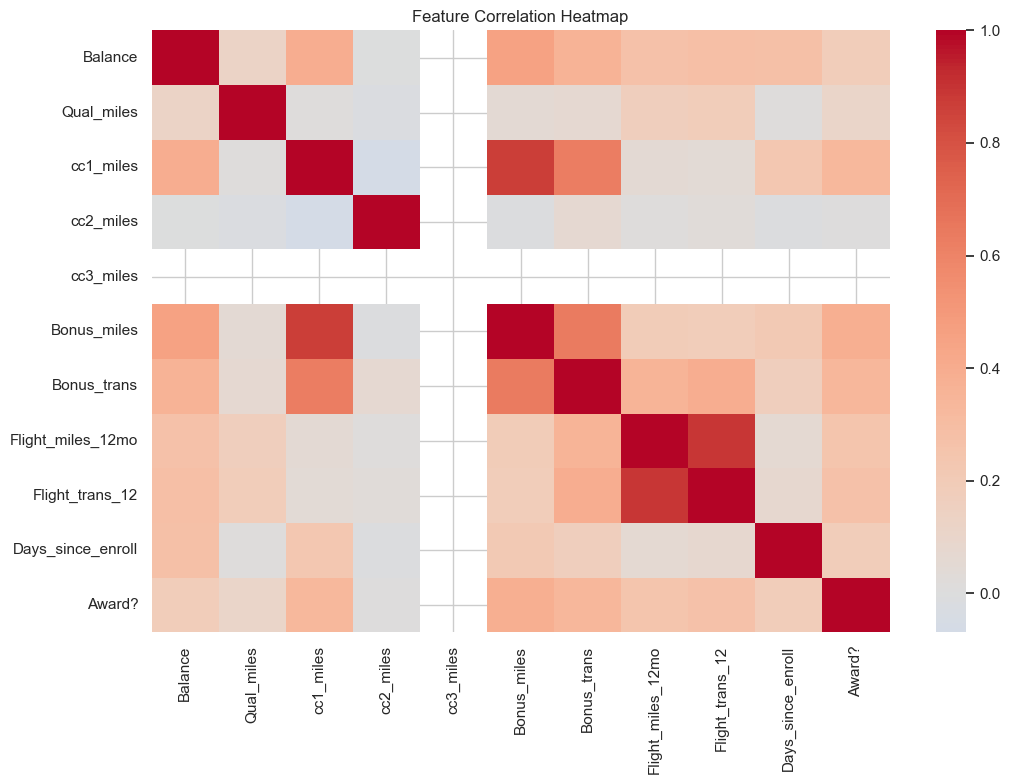

In [6]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(X_clean.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 2. K-Means Clustering

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

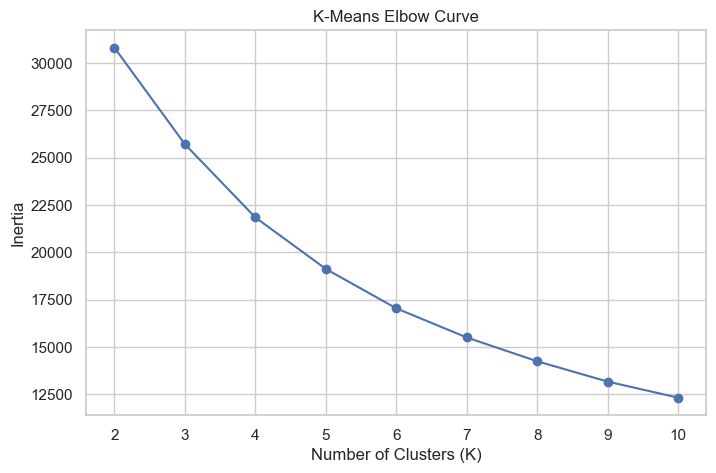

In [7]:
# Elbow curve
k_range = range(2, 11)
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.show()

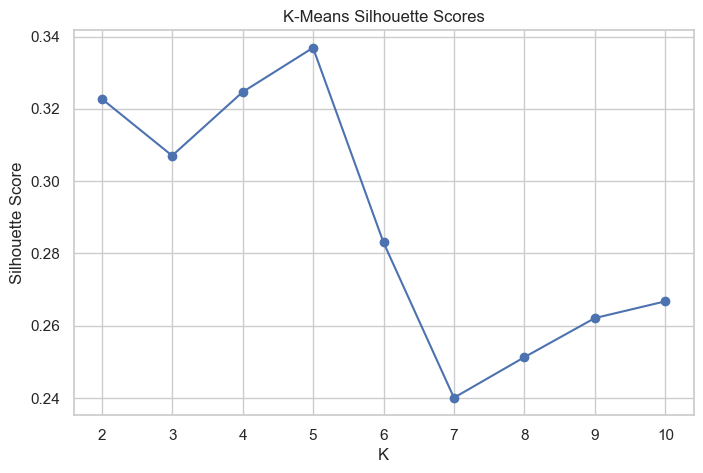

Selected K: 5
K-Means silhouette: 0.3369


In [11]:
# Evaluate K values using silhouette score and choose the best K.
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X_scaled)

k_silhouette = silhouette_score(X_scaled, k_labels)
print("Selected K:", best_k)
print("K-Means silhouette:", round(k_silhouette, 4))

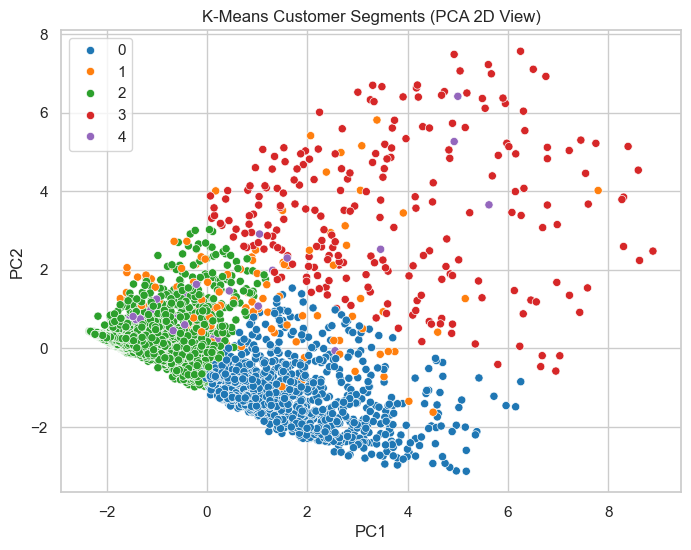

In [12]:
# 2D visualization using PCA only for plotting
from sklearn.decomposition import PCA

pca_plot = PCA(n_components=2, random_state=42)
X_2d = pca_plot.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=k_labels, palette="tab10", s=35, legend="full")
plt.title("K-Means Customer Segments (PCA 2D View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 3. DBSCAN Clustering

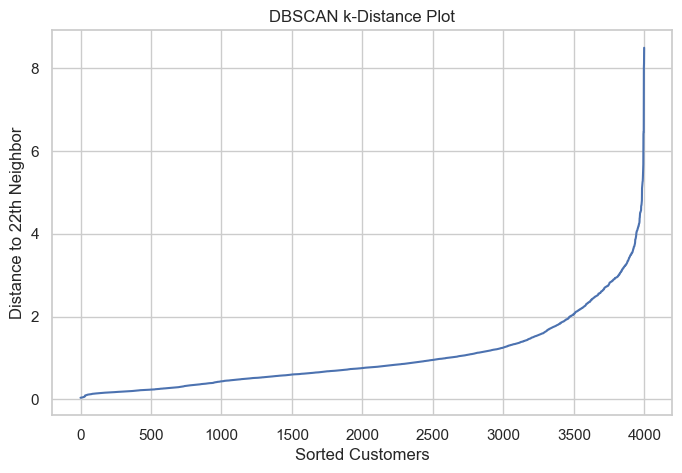

,eps,Clusters,Noise %,Silhouette
0,1.0,2,23.7809,0.3242
1,1.2,2,17.8795,0.3036
2,1.4,2,14.7537,0.2976
3,1.6,3,11.4029,0.2923
4,1.8,3,9.5774,0.2862
5,2.0,3,8.1520,0.2826
6,2.2,3,6.0765,0.5609
7,2.4,2,4.6012,0.6749
8,2.6,2,3.7509,0.6705
9,2.8,2,2.1755,0.6591


Selected eps: 2.3999999999999995
min_samples: 22
DBSCAN clusters: 2
Noise: 4.6 %
DBSCAN silhouette (excluding noise): 0.6749


In [13]:
# Estimate a reasonable epsilon using the k-nearest-neighbor distance curve.
# min_samples is commonly chosen around 2 * number of dimensions.
min_samples = 2 * X_scaled.shape[1]
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.xlabel("Sorted Customers")
plt.ylabel(f"Distance to {min_samples}th Neighbor")
plt.title("DBSCAN k-Distance Plot")
plt.show()

# Try several eps values and keep the one with the best valid silhouette.
eps_values = np.arange(1.0, 3.01, 0.2)
db_results = []

for eps in eps_values:
    db = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100

    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X_scaled[mask], labels[mask])
    else:
        sil = np.nan

    db_results.append([eps, n_clusters, noise_pct, sil])

db_table = pd.DataFrame(db_results, columns=["eps","Clusters","Noise %","Silhouette"])
display(db_table.round(4))

valid = db_table.dropna(subset=["Silhouette"])
if len(valid):
    best_eps = float(valid.loc[valid["Silhouette"].idxmax(), "eps"])
else:
    best_eps = 1.8

dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

db_mask = db_labels != -1
db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise = (db_labels == -1).mean() * 100
db_silhouette = silhouette_score(X_scaled[db_mask], db_labels[db_mask]) if db_clusters >= 2 else np.nan

print("Selected eps:", best_eps)
print("min_samples:", min_samples)
print("DBSCAN clusters:", db_clusters)
print("Noise:", round(db_noise, 2), "%")
print("DBSCAN silhouette (excluding noise):", round(db_silhouette, 4) if not np.isnan(db_silhouette) else "Not defined")

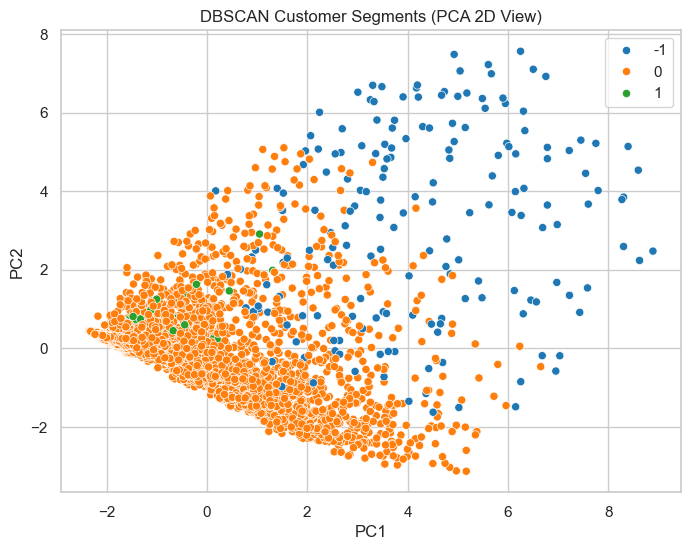

In [15]:
# DBSCAN visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=db_labels, palette="tab10", s=35, legend="full")
plt.title("DBSCAN Customer Segments (PCA 2D View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 4. Cluster Analysis & Interpretation

In [16]:
# Profile K-Means clusters using original feature units
profile = X_clean.copy()
profile["KMeans_Cluster"] = k_labels

cluster_profile = profile.groupby("KMeans_Cluster").mean().round(2)
cluster_sizes = profile["KMeans_Cluster"].value_counts().sort_index()

print("K-Means cluster sizes:")
display(cluster_sizes.to_frame("Customers"))
print("K-Means cluster profile:")
display(cluster_profile)

# Add a compact relative interpretation
overall_mean = X_clean.mean()
print("Interpretation guide: cluster means above the overall mean indicate relatively higher activity on that feature.")

K-Means cluster sizes:


,Customers
KMeans_Cluster,
0,1216
1,110
2,2402
3,228
4,43


K-Means cluster profile:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,111064.26,23.03,3.72,1.0,1.0,38395.05,18.44,254.58,0.76,4857.41,0.62
1,101191.47,3120.85,2.04,1.0,1.0,19171.87,11.77,672.88,2.10,4101.04,0.59
2,41610.22,16.10,1.22,1.0,1.0,4411.49,6.70,156.07,0.51,3708.77,0.20
3,151969.98,324.92,2.24,1.0,1.0,30428.70,24.01,3979.22,11.70,4553.79,0.77
4,68876.58,23.26,1.14,2.0,1.0,14689.84,17.35,582.63,2.09,3968.77,0.40


Interpretation guide: cluster means above the overall mean indicate relatively higher activity on that feature.


In [17]:
# Compare final metrics
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Clusters": [best_k, db_clusters],
    "Silhouette Score": [k_silhouette, db_silhouette],
    "Noise %": [0, db_noise]
})
display(comparison.round(4))

,Algorithm,Clusters,Silhouette Score,Noise %
0,K-Means,5,0.3369,0.0000
1,DBSCAN,2,0.6749,4.6012


## 5. Findings & Practical Insights

- **K-Means** creates every customer segment explicitly and is useful when the business expects a fixed number of customer groups.
- **DBSCAN** can discover irregular groups and identify unusual customers as noise/outliers, but its result is sensitive to `eps` and `min_samples`.
- Silhouette score is higher when clusters are compact and well separated; therefore it is useful for comparing clustering quality.
- Customer profiles can be used to distinguish high-value/high-flight customers, reward-focused customers, and lower-engagement customers.
- For airline marketing, segments can support targeted promotions, loyalty campaigns, credit-card offers, and retention strategies.